<a href="https://colab.research.google.com/github/antoniomoraes85/antoniomoraes85/blob/main/projeto_final_ibm_stock_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"

# Adiciona cabeçalho simulando um navegador real
headers = {"User-Agent": "Mozilla/5.0"}

# Faz a requisição com cabeçalho
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# Procura a tabela certa
tables = soup.find_all("table")
revenue_table = None

for table in tables:
    if "Quarterly Revenue" in table.text:
        revenue_table = table
        break

# Extrai os dados e limpa
if revenue_table:
    tesla_revenue = pd.read_html(str(revenue_table))[0]
    tesla_revenue.columns = ["Date", "Revenue"]
    tesla_revenue["Revenue"] = tesla_revenue["Revenue"].replace("[$,]", "", regex=True)
    tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"], errors="coerce")
    display(tesla_revenue.tail())
else:
    print("Tabela de receita da Tesla não encontrada.")


<ipython-input-8-6bbeb1e02574>:25: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tesla_revenue = pd.read_html(str(revenue_table))[0]


,Date,Revenue
59,2010-06-30,28.0
60,2010-03-31,21.0
61,2009-12-31,NaN
62,2009-09-30,46.0
63,2009-06-30,27.0


In [9]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
display(gme_data.head())


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [10]:
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

tables = soup.find_all("table")
revenue_table = None

for table in tables:
    if "Quarterly Revenue" in table.text:
        revenue_table = table
        break

if revenue_table:
    gme_revenue = pd.read_html(str(revenue_table))[0]
    gme_revenue.columns = ["Date", "Revenue"]
    gme_revenue["Revenue"] = gme_revenue["Revenue"].replace("[$,]", "", regex=True)
    gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"], errors='coerce')
    display(gme_revenue.tail())
else:
    print("Tabela de receita da GameStop não encontrada.")


<ipython-input-10-0dbab21b0463>:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  gme_revenue = pd.read_html(str(revenue_table))[0]


,Date,Revenue
60,2010-01-31,3524
61,2009-10-31,1835
62,2009-07-31,1739
63,2009-04-30,1981
64,2009-01-31,3492


In [12]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(stock_data['Date'], stock_data['Close'], color='blue', label='Stock Price')
    ax1.set_ylabel('Stock Price', color='blue')

    ax2 = ax1.twinx()
    ax2.plot(revenue_data['Date'], revenue_data['Revenue'], color='red', label='Revenue')
    ax2.set_ylabel('Revenue', color='red')

    plt.title(f'{stock} Stock Price vs Revenue')
    fig.legend()
    plt.show()


In [18]:
tesla_data['Date'] = pd.to_datetime(tesla_data['Date']).dt.tz_localize(None)
gme_data['Date'] = pd.to_datetime(gme_data['Date']).dt.tz_localize(None)

tesla_revenue['Date'] = pd.to_datetime(tesla_revenue['Date'])
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'])


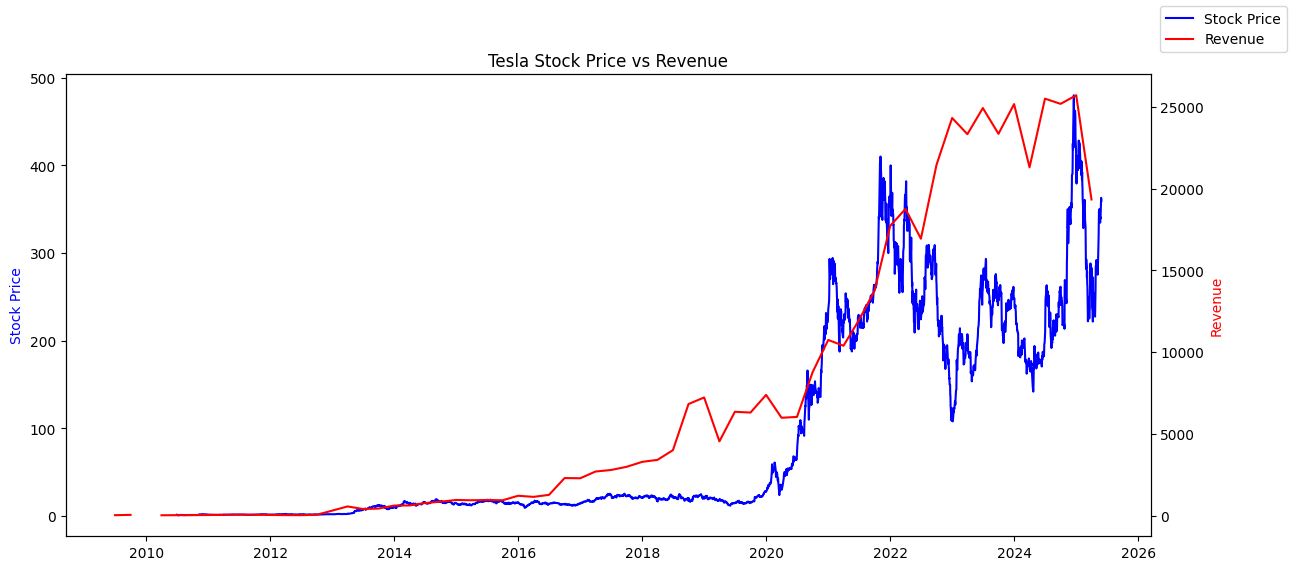

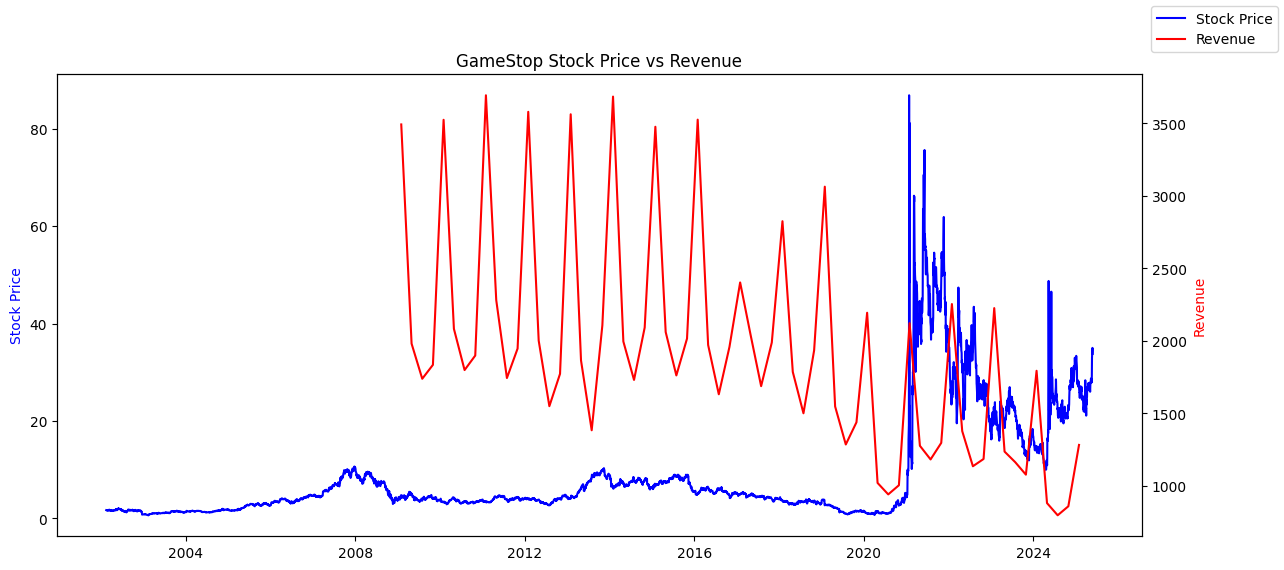

In [19]:
make_graph(tesla_data, tesla_revenue, "Tesla")
make_graph(gme_data, gme_revenue, "GameStop")
